# Import Packages

In [49]:
import os

import numpy as np
import pandas as pd

import statsmodels.api as sm
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# Import Data

In [50]:
data_dir   = os.path.join("..", "data")

df_daily   = pd.read_parquet(os.path.join(data_dir, "combined_daily.parquet"))
# df_weekly  = pd.read_parquet(os.path.join(data_dir, "combined_weekly.parquet"))
df_monthly = pd.read_parquet(os.path.join(data_dir, "combined_monthly.parquet"))

# Functions

## Correlation & Regression

In [81]:
def calculate_metrics(df, industry):
    """
    Performs correlation and multiple linear regression analysis between 
    publication/citation activity (and their time-lagged versions) and ETF price data.

    Parameters:
        df (pd.DataFrame): DataFrame containing publication and citation counts (including lagged versions), 
                           ETF sector price data (e.g., 'close', 'pct_change_close', 'close_vol_3d'), 
                           and metadata including 'industry' and 'date'.
        industry (str): Name of the industry sector to filter the analysis on (e.g., 'Technology', 'Healthcare').

    Returns:
        results (pd.DataFrame): Summary table containing:
            - Pearson correlation coefficients between each predictor and:
                * ETF closing price
                * Daily percentage change in closing price
                * 3-day price volatility
            - Beta coefficients and p-values from a multiple linear regression model with 
              'pct_change_close' as the dependent variable.

        r_squared_mlr (float): R-squared value indicating the explanatory power of the regression model.
    """
    # Filter by industry and date
    df_filtered = df[(df['industry'] == industry) & (df['date'] >= '2025-04-01')].copy()
    df_filtered = df_filtered.fillna(0)  # Replace missing values with 0

    # Define predictor variables
    publication_variables = ['publications', 'publications_1', 'publications_3', 'publications_7', 'publications_14', 'publications_30']
    citation_variables    = ['citations', 'citations_1', 'citations_3', 'citations_7', 'citations_14', 'citations_30']
    predictors            = publication_variables + citation_variables

    # Initialize results DataFrame
    results = pd.DataFrame(index = ['beta', 'p_value', 'correlation_close', 
                                    'correlation_pct_change_close', 'correlation_volatility'
                                   ],
                           columns = predictors)

    # Loop through each predictor for correlation analysis
    for var in predictors:
        # Correlations
        results.at['correlation_close', var]            = stats.pearsonr(df_filtered[var], df_filtered['close'])[0]
        results.at['correlation_pct_change_close', var] = stats.pearsonr(df_filtered[var], df_filtered['pct_change_close'])[0]
        results.at['correlation_volatility', var]       = stats.pearsonr(df_filtered[var], df_filtered['close_vol_3d'])[0]

    # Fit Multiple Linear Regression model
    X_mlr     = sm.add_constant(df_filtered[predictors])
    y_mlr     = df_filtered['pct_change_close']
    mlr_model = sm.OLS(y_mlr, X_mlr).fit()

    # Extract full MLR beta coefficients and p-values
    mlr_summary = pd.DataFrame({'beta_mlr': mlr_model.params.drop('const'),
                                'p_value_mlr': mlr_model.pvalues.drop('const')
                              })

    # Populate beta and p_value rows in results table
    results.loc['beta', mlr_summary.index]    = mlr_summary['beta_mlr']
    results.loc['p_value', mlr_summary.index] = mlr_summary['p_value_mlr']

    # Extract adjust R² of the full model
    adjusted_r_squared_mlr = round(mlr_model.rsquared_adj * 100, 2)

    return results, adjusted_r_squared_mlr


## Visualize Trends

In [95]:
def plot_close_vs_publications(df, industry):
    """
    Generates a dual-axis plot of ETF sector closing prices and publication volume over time for a given industry.

    Parameters:
        df (pd.DataFrame): DataFrame containing industry-specific ETF data, including 
                           'date', 'close' prices, and 'publications' counts.
        industry (str): The name of the industry sector to filter and visualize (e.g., 'Technology').

    Returns:
        matplotlib.figure.Figure: The matplotlib figure object containing the plot.
    """
    # Filter the dataset for the specific industry and date range
    df_filtered = df[(df['industry'] == industry) & (df['date'] >= '2025-03-01')].copy()
    
    # Ensure that the 'date' column is of datetime type
    df_filtered['date'] = pd.to_datetime(df_filtered['date'])
    
    # Create a figure and axis
    fig, ax1 = plt.subplots(figsize = (12, 6))

    # Plot the 'close' price
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Close Price ($)', color = 'tab:blue')
    ax1.plot(df_filtered['date'], df_filtered['close'], color = 'tab:blue', label = 'Close Price', marker = 'o')
    ax1.tick_params(axis = 'y', labelcolor = 'tab:blue')
    
    # Create a second y-axis to plot publications
    ax2 = ax1.twinx()
    ax2.set_ylabel('Publications', color = 'tab:green')
    ax2.bar(df_filtered['date'], df_filtered['publications'], color = 'tab:green', alpha = 0.6, label = 'Publications')
    ax2.tick_params(axis = 'y', labelcolor = 'tab:green')
    
    # Add title and layout
    plt.title(f'Close Price and Publications for {industry} (From March 2025)', fontsize = 14)
    fig.tight_layout()
    
    return fig

# Inference

In [ ]:
sector_etfs = {"Energy": "XLE", "Materials": "XLB", "Industrials": "XLI", "Healthcare": "XLV",
               "Financials": "XLF", "Technology": "XLK", "Telecommunication Services": "XLC",
               "Utilities": "XLU", "Real Estate": "XLRE", "Clean Energy": "ICLN", "Semiconductors": "SOXX",
               "Renewables": "TAN", "Cloud Computing": "SKYY", "Genomics": "ARKG",
              }

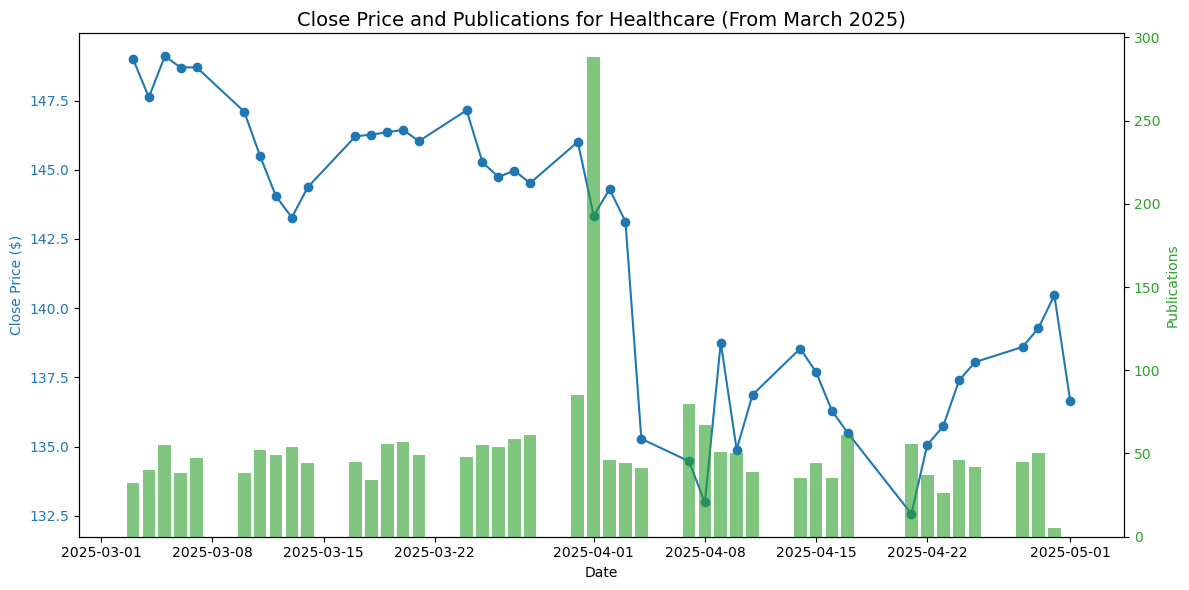

In [96]:
check = plot_close_vs_publications(df_daily, 'Healthcare')

In [83]:
metrics_table = calculate_metrics(df_daily, 'Healthcare')
metrics_table[0]

,publications,publications_1,publications_3,publications_7,publications_14,publications_30,citations,citations_1,citations_3,citations_7,citations_14,citations_30
beta,-0.025472,-0.008443,-0.028118,-0.012118,0.00219,0.013312,1.518762,0.311967,0.298267,0.724827,0.310359,-0.380879
p_value,0.087759,0.670341,0.031215,0.233031,0.807761,0.835695,0.15607,0.570118,0.535998,0.329072,0.396392,0.319906
correlation_close,0.303612,0.478141,-0.069579,-0.20186,-0.20279,-0.190564,0.629169,0.605447,-0.050317,-0.341148,-0.302987,0.334621
correlation_pct_change_close,-0.226009,0.078266,-0.649819,-0.271751,0.235217,-0.192848,0.017266,-0.113125,-0.465016,-0.258055,0.134156,-0.309429
correlation_volatility,0.008381,-0.072517,0.590829,0.2639,-0.11959,0.386149,-0.091531,-0.175518,0.769048,0.478797,0.109736,0.270696


In [84]:
metrics_table[1]

0.3144244580739307